In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

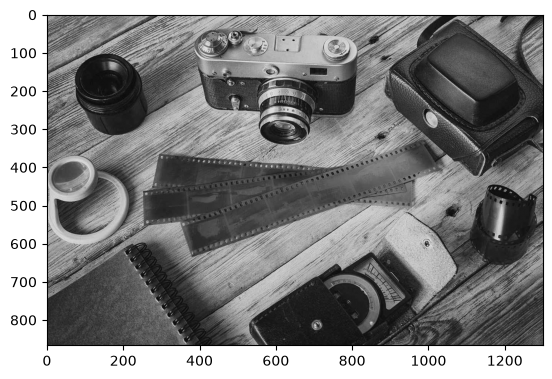

In [13]:
img = cv2.imread(r'C:\Users\Hp\Pictures\OpenCVSamples\samplecamera.jpg')

img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(img,cmap='gray')


# you can also just use img = cv2.imread(r'C:\Users\Hp\Pictures\OpenCVSamples\samplecamera.jpg',0)

Apply Image Negative


Why we do it: Inverting values requires subtracting each pixel from the maximum possible value (\(255\)).

How: Use NumPy's element-wise subtraction.

# Dark becomes bright, bright becomes dark
negative_img = 255 - img

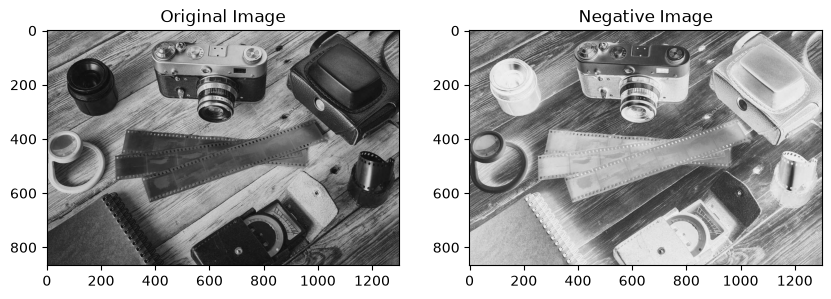

In [27]:
neg = 255 - img 

plt.figure(figsize = (10,10))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(neg,cmap='gray')
plt.title('Negative Image')

plt.show()

Apply Log Transformation


Why we do it: You must calculate your constant scaling factor \(c\) dynamically based on your image's maximum value, apply the log function, and then convert the floating-point result back into standard 8-bit integers (uint8).

How:

NaN. Calculate \(c\): c = 255 / (np.log(1 + np.max(img))).

NaN. Compute the log array: log_transformed = c * np.log(1 + img).

NaN. Convert the data type: log_transformed = np.array(log_transformed, dtype=np.uint8).

To avoid overflowing error

```text
uint8 image
    ↓
convert to float32
    ↓
mathematical transformation
    ↓
convert back to uint8
    ↓
display / save

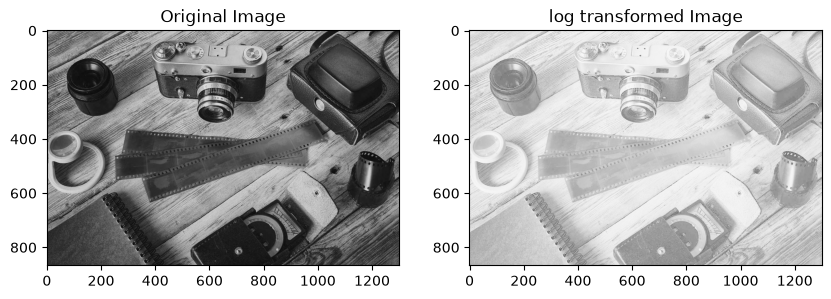

In [28]:
img = img.astype(np.float32)
c = 255 / (np.log(1 + np.max(img)))
log_transformed = c * np.log(1 + img)

log_transformed = np.array(log_transformed, dtype=np.uint8)

plt.figure(figsize = (10,10))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(log_transformed,cmap='gray')
plt.title('log transformed Image')

plt.show()  

        

Apply Gamma Transformation

Why we do it: To avoid math overflow, you must scale your standard 0-255 integers to a decimal scale of 0.0 to 1.0 before raising them to an exponent, and then scale them back up.

How:

NaN. Divide your image by 255.0 to normalize it.

NaN. Raise the result to your gamma exponent (\(\gamma\)).

NaN. Multiply by 255 and cast the result back to uint8.

gamma = 0.5  # Brightens the image
gamma_corrected = np.array(255 * (img / 255) ** gamma, dtype='uint8')

```text

uint8 image
    ↓
normalize to 0–1
    ↓
apply gamma power
    ↓
scale back to 0–255
    ↓
convert to uint8

why convert the image in unit8 at last when it is already in unit8 at the starting 

```texts
             Original image
                  │
                uint8
                  │
                  ▼
             img / 255 (float)
                  │
                  ▼
            ** gamma (float)
                  │
                  ▼
               × 255 (float)
                  │
                  ▼
             dtype=uint8
                  │
                  ▼
          Final image (0–255)

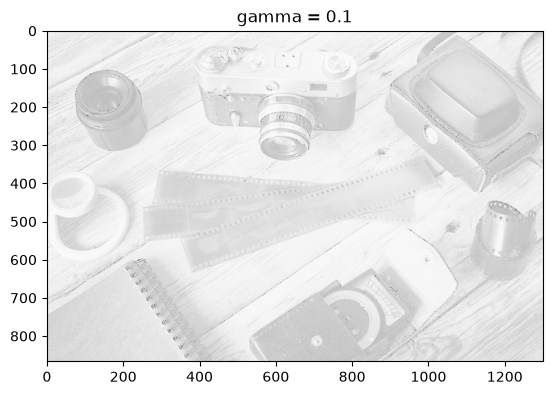

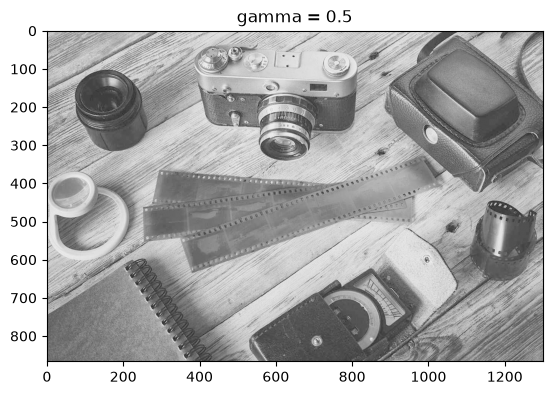

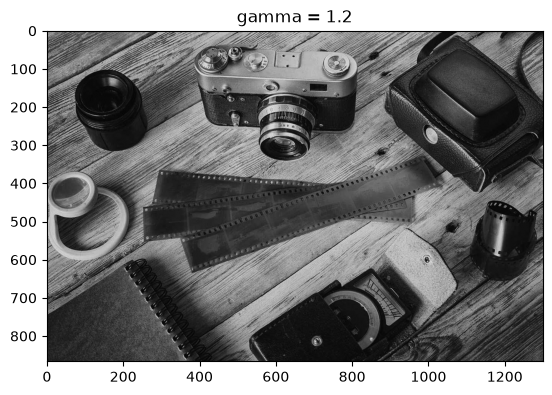

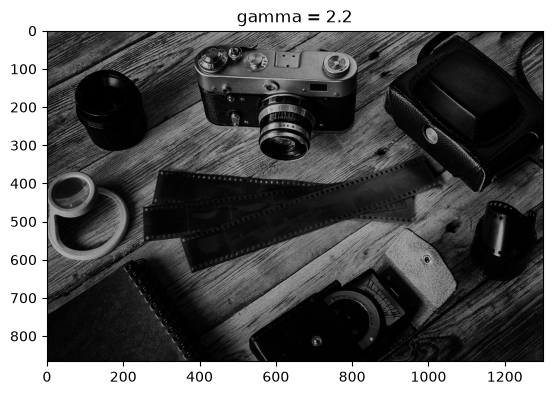

In [29]:
# Trying 4 gamma values.
for gamma in [0.1, 0.5, 1.2, 2.2]:
    
    # Apply gamma correction.
    gamma_corrected = np.array(255*(img / 255) ** gamma, dtype = 'uint8')

    # display images.
    plt.imshow(gamma_corrected , cmap = 'gray')
    plt.title('gamma = ' + str(gamma))
    plt.show()
    


Apply Contrast Stretching

Why we do it: To map pixel thresholds dynamically using our piecewise slopes.

How:

NaN. Write a basic helper function pixelVal(pix, r1, s1, r2, s2) using if-elif-else branches to calculate the output value based on the three zone equations.

NaN. Vectorize this function: pixelVal_vec = np.vectorize(pixelVal).

NaN. Pass your image and threshold parameters (e.g., \(r_1=70, s_1=0, r_2=140, s_2=255\)) through this vectorized function.

``` texts
0 ───────── r1 ───────── r2 ───────── 255
     Region 1     Region 2     Region 3


Output
255 |             ┌────────────────────
    |            /
    |           /
    |          /
    |         /
  0 |────────┘
    +---------------------------------- Input
     0       r1      r2           255

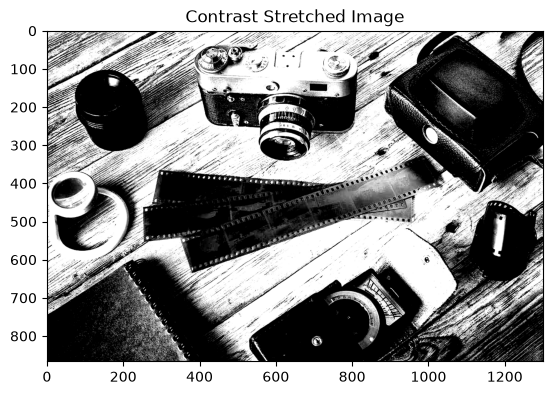

In [30]:
def pixelVal(pix, r1, s1, r2, s2):
    if 0 <= pix <= r1:
        return (s1 / r1) * pix
    elif r1 < pix <= r2:
        return ((s2 - s1) / (r2 - r1)) * (pix - r1) + s1
    else:
        return ((255 - s2) / (255 - r2)) * (pix - r2) + s2

r1 = 70
s1 = 0
r2 = 140
s2 = 255

pixelVal_vec = np.vectorize(pixelVal)

contrast_stretched = pixelVal_vec(img, r1, s1, r2, s2)

contrast_stretched = np.array(contrast_stretched,dtype=np.uint8)

plt.imshow(contrast_stretched, cmap='gray')
plt.title('Contrast Stretched Image')
plt.show()